# HW14 — эмбеддинги, FAISS, оценка retrieval, обновление базы знаний, mini-RAG

База знаний: учебные заметки по **Git и GitHub** (локальный JSON `knowledge_base.json`).

Пайплайн: загрузка → чанкинг → **TF-IDF + L2-нормализация** (разрежённые векторы приводятся к плотному виду для FAISS) → индекс **FAISS** (`IndexFlatIP`, косинусное сходство) → метрики → эксперимент `top_k` → добавление документов и переиндексация → mini-RAG (extractive) → артефакты в `artifacts/`.

Зависимости: `numpy`, `pandas`, `scikit-learn`, `faiss-cpu`, `matplotlib`.


## 2.3.1 Импорты, seed и среда


In [1]:
# При необходимости: %pip install -q faiss-cpu matplotlib pandas scikit-learn numpy
import json
import random
import re
from pathlib import Path
from typing import Any

import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

VECTORIZER_KIND = "TfidfVectorizer(max_features=4000, ngram_range=(1,2), min_df=1) + L2"


def resolve_hw14_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "HW14.ipynb").exists():
        return cwd
    p = cwd / "homeworks" / "HW14"
    if p.is_dir() and (p / "HW14.ipynb").exists():
        return p
    return cwd


BASE = resolve_hw14_root()
ARTIFACT_DIR = BASE / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
KB_PATH = BASE / "knowledge_base.json"
print("BASE:", BASE.resolve())
print("ARTIFACT_DIR:", ARTIFACT_DIR.resolve())


BASE: /Users/cvacushka/Desktop/aie-student-template/homeworks/HW14
ARTIFACT_DIR: /Users/cvacushka/Desktop/aie-student-template/homeworks/HW14/artifacts


## 2.3.2 База знаний и первичный анализ


In [2]:
with open(KB_PATH, "r", encoding="utf-8") as f:
    kb_raw: dict[str, Any] = json.load(f)

docs_initial = list(kb_raw["documents"])
docs_update_extra = list(kb_raw["documents_update"])
print("Тема:", kb_raw.get("topic"))
print("Число документов (начальная база):", len(docs_initial))
print("Документов для обновления (будут добавлены позже):", len(docs_update_extra))
display_df = pd.DataFrame([{"id": d["id"], "title": d["title"], "n_chars": len(d["text"])} for d in docs_initial])
display(display_df.head())
print("\nПримеры текста (первые ~220 символов):\n")
for d in docs_initial[:3]:
    print("---", d["id"], d["title"])
    print(d["text"][:220].replace("\n", " "), "...\n")


Тема: Git, GitHub и командная работа над кодом
Число документов (начальная база): 15
Документов для обновления (будут добавлены позже): 3


,id,title,n_chars
0,doc_01,Клонирование репозитория,405
1,doc_02,Коммиты и сообщения,356
2,doc_03,Ветки,326
3,doc_04,Слияние веток,362
4,doc_05,Rebase,355



Примеры текста (первые ~220 символов):

--- doc_01 Клонирование репозитория
Команда git clone копирует удалённый репозиторий на локальную машину вместе с историей коммитов. Обычно используют HTTPS или SSH URL. После клонирования появляется папка проекта с подкаталогом .git. Чтобы клонировать тол ...

--- doc_02 Коммиты и сообщения
Коммит фиксирует снимок файлов в репозитории. Сообщение коммита должно кратко объяснять, зачем сделано изменение. Хорошая практика: одна логическая правка на один коммит. Перед коммитом просматривают изменения через git  ...

--- doc_03 Ветки
Ветка — это указатель на коммит. Основная ветка часто называется main или master. Новая ветка создаётся командой git branch имя или git checkout -b имя. Работа в отдельной ветке позволяет изолировать фичу или исправление ...



## 2.3.3 Чанкинг документов

Символьное скользящее окно: `chunk_size=480`, `overlap=90`.


In [3]:
CHUNK_SIZE = 480
OVERLAP = 90


def chunk_document(text: str, chunk_size: int, overlap: int) -> list[str]:
    text = text.strip()
    if not text:
        return []
    step = max(chunk_size - overlap, 1)
    chunks: list[str] = []
    start = 0
    while start < len(text):
        piece = text[start : start + chunk_size]
        chunks.append(piece)
        start += step
        if start >= len(text):
            break
    return chunks


def build_corpus(documents: list[dict], chunk_size: int, overlap: int) -> tuple[list[dict], pd.DataFrame]:
    rows: list[dict] = []
    for doc in documents:
        for j, ch in enumerate(chunk_document(doc["text"], chunk_size, overlap)):
            cid = f"{doc['id']}__{j}"
            rows.append(
                {
                    "chunk_id": cid,
                    "doc_id": doc["id"],
                    "title": doc["title"],
                    "text": ch,
                }
            )
    meta = pd.DataFrame(rows)
    return rows, meta


chunks_initial, meta_initial = build_corpus(docs_initial, CHUNK_SIZE, OVERLAP)
print("Число чанков (начальная база):", len(meta_initial))
sample_doc = docs_initial[2]
parts = chunk_document(sample_doc["text"], CHUNK_SIZE, OVERLAP)
print(f"\nПример: документ {sample_doc['id']} разбит на {len(parts)} чанков")
for i, p in enumerate(parts[:2]):
    print(f"--- chunk {i} ({len(p)} символов) ---")
    print(p[:300], "..." if len(p) > 300 else "")


Число чанков (начальная база): 16

Пример: документ doc_03 разбит на 1 чанков
--- chunk 0 (326 символов) ---
Ветка — это указатель на коммит. Основная ветка часто называется main или master. Новая ветка создаётся командой git branch имя или git checkout -b имя. Работа в отдельной ветке позволяет изолировать фичу или исправление. Переключение между ветками выполняют git checkout или git switch. Список веток ...


## 2.3.4 Эмбеддинги и индекс FAISS


In [4]:
def fit_vectorizer_and_index(meta: pd.DataFrame) -> tuple[TfidfVectorizer, faiss.Index, np.ndarray]:
    vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=1)
    X = vectorizer.fit_transform(meta["text"].tolist())
    X = normalize(X, norm="l2", axis=1)
    dense = np.asarray(X.todense(), dtype="float32")
    dim = dense.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(dense)
    return vectorizer, index, dense


def retrieve(
    query: str,
    meta: pd.DataFrame,
    vectorizer: TfidfVectorizer,
    index: faiss.Index,
    top_k: int,
) -> pd.DataFrame:
    q = vectorizer.transform([query])
    q = normalize(q, norm="l2", axis=1)
    qd = np.asarray(q.todense(), dtype="float32")
    scores, idxs = index.search(qd, top_k)
    rows = []
    for rank, (score, ix) in enumerate(zip(scores[0], idxs[0]), start=1):
        row = meta.iloc[int(ix)].to_dict()
        row["score"] = float(score)
        row["rank"] = rank
        rows.append(row)
    return pd.DataFrame(rows)


vectorizer_initial, index_initial, _ = fit_vectorizer_and_index(meta_initial)
print("Размерность векторов (TF-IDF):", _.shape[1])

demo_queries = [
    "Как клонировать удалённый репозиторий?",
    "Что делать при конфликте при слиянии веток?",
    "Как временно спрятать незакоммиченные правки?",
    "Зачем нужен файл gitignore",
    "Как настроить доступ по SSH к GitHub",
]
for dq in demo_queries:
    print("\n===", dq)
    display(retrieve(dq, meta_initial, vectorizer_initial, index_initial, top_k=3)[["rank", "doc_id", "title", "score"]])


Размерность векторов (TF-IDF): 975

=== Как клонировать удалённый репозиторий?


,rank,doc_id,title,score
0,1,doc_01,Клонирование репозитория,0.174091
1,2,doc_14,GitHub Actions — введение,0.055645
2,3,doc_15,Субмодули,0.034534



=== Что делать при конфликте при слиянии веток?


,rank,doc_id,title,score
0,1,doc_11,История и просмотр коммитов,0.102435
1,2,doc_04,Слияние веток,0.097685
2,3,doc_05,Rebase,0.079308



=== Как временно спрятать незакоммиченные правки?


,rank,doc_id,title,score
0,1,doc_10,Git stash,0.112749
1,2,doc_14,GitHub Actions — введение,0.068958
2,3,doc_02,Коммиты и сообщения,0.000000



=== Зачем нужен файл gitignore


,rank,doc_id,title,score
0,1,doc_06,Файл .gitignore,0.223420
1,2,doc_02,Коммиты и сообщения,0.055292
2,3,doc_01,Клонирование репозитория,0.000000



=== Как настроить доступ по SSH к GitHub


,rank,doc_id,title,score
0,1,doc_07,SSH-ключи для GitHub,0.271500
1,2,doc_14,GitHub Actions — введение,0.198657
2,3,doc_01,Клонирование репозитория,0.043514


## 2.3.5 Контрольные запросы и оценка retrieval


In [5]:
CONTROL_QUERIES: list[dict[str, str]] = [
    {"query": "Как скопировать репозиторий с сервера на компьютер?", "expected": "doc_01"},
    {"query": "Как писать сообщения к коммитам и что такое amend?", "expected": "doc_02"},
    {"query": "Как создать новую ветку и переключаться между ветками?", "expected": "doc_03"},
    {"query": "Как объединить feature-ветку в main?", "expected": "doc_04"},
    {"query": "Что делает git rebase и когда он опасен?", "expected": "doc_05"},
    {"query": "Какие файлы не нужно коммитить в Python-проекте?", "expected": "doc_06"},
    {"query": "Как настроить ключи SSH для GitHub?", "expected": "doc_07"},
    {"query": "Что такое pull request и зачем описание?", "expected": "doc_08"},
    {"query": "Как разрешить конфликт слияния с маркерами в файле?", "expected": "doc_09"},
    {"query": "Что делает git stash и как вернуть изменения?", "expected": "doc_10"},
]

K_EVAL = 5


def eval_retrieval(
    meta: pd.DataFrame,
    vectorizer: TfidfVectorizer,
    index: faiss.Index,
    k: int,
) -> tuple[pd.DataFrame, dict]:
    records: list[dict] = []
    hits = []
    recalls = []
    ranks = []
    for item in CONTROL_QUERIES:
        q = item["query"]
        exp = item["expected"]
        res = retrieve(q, meta, vectorizer, index, top_k=k)
        doc_ids_order = res["doc_id"].tolist()
        try:
            rank_first = next(i + 1 for i, d in enumerate(doc_ids_order) if d == exp)
        except StopIteration:
            rank_first = 0
        hit = int(exp in set(doc_ids_order))
        hits.append(hit)
        recalls.append(hit)
        ranks.append(rank_first)
        records.append(
            {
                "query": q,
                "expected_source": exp,
                "retrieved_sources": " | ".join(res["doc_id"].tolist()),
                "hit_at_k": hit,
                "rank_of_first_relevant": rank_first,
            }
        )
    df_eval = pd.DataFrame(records)
    metrics = {
        f"hit@{k}": float(np.mean(hits)),
        f"recall@{k}": float(np.mean(recalls)),
        f"MRR@{k}": float(np.mean([1.0 / r if r > 0 else 0.0 for r in ranks])),
    }
    return df_eval, metrics


retrieval_eval_df, metrics_main = eval_retrieval(meta_initial, vectorizer_initial, index_initial, K_EVAL)
print(metrics_main)
display(retrieval_eval_df.head())


{'hit@5': 1.0, 'recall@5': 1.0, 'MRR@5': 0.925}


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Как скопировать репозиторий с сервера на компь...,doc_01,doc_12 | doc_14 | doc_08 | doc_01 | doc_15,1,4
1,Как писать сообщения к коммитам и что такое am...,doc_02,doc_02 | doc_14 | doc_12 | doc_04 | doc_03,1,1
2,Как создать новую ветку и переключаться между ...,doc_03,doc_03 | doc_14 | doc_04 | doc_10 | doc_02,1,1
3,Как объединить feature-ветку в main?,doc_04,doc_04 | doc_05 | doc_14 | doc_10 | doc_03,1,1
4,Что делает git rebase и когда он опасен?,doc_05,doc_05 | doc_12 | doc_09 | doc_02 | doc_01,1,1


## 2.3.6 Эксперимент: сравнение `top_k` (3 vs 5)


In [6]:
_, m3 = eval_retrieval(meta_initial, vectorizer_initial, index_initial, 3)
_, m5 = eval_retrieval(meta_initial, vectorizer_initial, index_initial, 5)
exp_df = pd.DataFrame([{"setting": "top_k=3", **m3}, {"setting": "top_k=5", **m5}])
display(exp_df)
print("Вывод: при большем k обычно не падает hit@k; иногда растёт recall за счёт дополнительных кандидатов.")


,setting,hit@3,recall@3,MRR@3,hit@5,recall@5,MRR@5
0,top_k=3,0.9,0.9,0.9,NaN,NaN,NaN
1,top_k=5,NaN,NaN,NaN,1.0,1.0,0.925


Вывод: при большем k обычно не падает hit@k; иногда растёт recall за счёт дополнительных кандидатов.


## 2.3.7 Обновление базы знаний и переиндексация


In [7]:
docs_after = docs_initial + docs_update_extra
chunks_after, meta_after = build_corpus(docs_after, CHUNK_SIZE, OVERLAP)
vectorizer_after, index_after, _ = fit_vectorizer_and_index(meta_after)
print("Документов после обновления:", len(docs_after), "| чанков:", len(meta_after))

COMPARE_QUERIES = [
    "Как автоматически запускать линтер перед коммитом?",
    "Как хранить большие модели и бинарники в Git?",
    "Что такое conventional commits и типы feat/fix?",
    "Как клонировать репозиторий с сервера?",
]

before_after_rows: list[dict] = []
for cq in COMPARE_QUERIES:
    b = retrieve(cq, meta_initial, vectorizer_initial, index_initial, top_k=5)
    a = retrieve(cq, meta_after, vectorizer_after, index_after, top_k=5)
    before_after_rows.append(
        {
            "query": cq,
            "before_retrieved_sources": " | ".join(b["doc_id"].tolist()),
            "after_retrieved_sources": " | ".join(a["doc_id"].tolist()),
            "changed": " | ".join(b["doc_id"].tolist()) != " | ".join(a["doc_id"].tolist()),
        }
    )

before_after_df = pd.DataFrame(before_after_rows)
display(before_after_df)
print("Для вопросов про pre-commit, LFS и conventional commits после обновления в топе появляются doc_16/doc_17/doc_18.")


Документов после обновления: 18 | чанков: 19


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как автоматически запускать линтер перед комми...,doc_02 | doc_14 | doc_04 | doc_12 | doc_15,doc_02 | doc_14 | doc_16 | doc_04 | doc_15,True
1,Как хранить большие модели и бинарники в Git?,doc_14 | doc_01 | doc_01 | doc_03 | doc_12,doc_17 | doc_14 | doc_01 | doc_01 | doc_03,True
2,Что такое conventional commits и типы feat/fix?,doc_12 | doc_02 | doc_04 | doc_03 | doc_01,doc_18 | doc_12 | doc_02 | doc_04 | doc_03,True
3,Как клонировать репозиторий с сервера?,doc_01 | doc_14 | doc_15 | doc_12 | doc_04,doc_01 | doc_14 | doc_15 | doc_12 | doc_16,True


Для вопросов про pre-commit, LFS и conventional commits после обновления в топе появляются doc_16/doc_17/doc_18.


## 2.3.8 Mini-RAG и 2.3.9 Анализ ошибок


In [8]:
STOPWORDS = {"и", "в", "на", "с", "по", "для", "как", "что", "к", "из", "не", "а", "о", "у", "же", "ли", "или"}


def tokenize_ru(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^\w\s]+", " ", text, flags=re.UNICODE)
    return [t for t in text.split() if t and t not in STOPWORDS]


def extractive_answer(question: str, ctx_rows: pd.DataFrame) -> str:
    """Простой учебный ответ: предложение из чанков с максимальным пересечением по токенам с вопросом."""
    if ctx_rows.empty:
        return "Недостаточно контекста."
    q_toks = set(tokenize_ru(question))
    best_score = -1.0
    best_sentence = ""
    for text in ctx_rows["text"]:
        for sent in re.split(r"(?<=[.!?])\s+", text):
            if len(sent) < 20:
                continue
            st = set(tokenize_ru(sent))
            inter = len(q_toks & st)
            score = inter / (len(st) + 1e-6)
            if score > best_score:
                best_score = score
                best_sentence = sent.strip()
    if not best_sentence:
        best_sentence = ctx_rows.iloc[0]["text"].strip()[:400]
    return best_sentence


def mini_rag(
    question: str,
    meta: pd.DataFrame,
    vectorizer: TfidfVectorizer,
    index: faiss.Index,
    top_k: int = 4,
) -> dict:
    hits = retrieve(question, meta, vectorizer, index, top_k=top_k)
    ans = extractive_answer(question, hits)
    sources = hits[["doc_id", "title", "score"]].copy()
    sources["source_label"] = sources["title"] + " (" + sources["doc_id"] + ")"
    return {"answer": ans, "sources": sources}


rag_questions = [
    "Как отложить незакоммиченные изменения и вернуть их потом?",
    "Что такое GitHub Actions и где лежит конфиг?",
    "Как помечают версии релизов в Git?",
    "Нужен ли Git LFS для маленьких текстовых файлов?",
    "Как оформить сообщение коммита по conventional commits?",
]

rag_rows: list[dict] = []
for rq in rag_questions:
    out = mini_rag(rq, meta_after, vectorizer_after, index_after, top_k=4)
    rag_rows.append(
        {
            "question": rq,
            "answer": out["answer"],
            "retrieved_sources": " | ".join(out["sources"]["source_label"].tolist()),
        }
    )

rag_df = pd.DataFrame(rag_rows)
display(rag_df)

print("\nКороткий разбор пограничных случаев:")
print("- Вопрос про Git LFS: качество зависит от retrieval; отрицательные формулировки плохо ловятся extractive-ответом.")
print("- Conventional commits: возможен выбор предложения не из doc_18, если в топе шум.")
print("- Extractive mini-RAG не генерирует новый текст — только выделяет фрагмент из контекста.")


,question,answer,retrieved_sources
0,Как отложить незакоммиченные изменения и верну...,Вернуть изменения можно git stash pop или git ...,Git stash (doc_10) | GitHub Actions — введение...
1,Что такое GitHub Actions и где лежит конфиг?,GitHub Actions запускает автоматизацию по собы...,GitHub Actions — введение (doc_14) | Pre-commi...
2,Как помечают версии релизов в Git?,Лёгкий тег: git tag v1.0.0.,Теги и релизы (doc_13) | GitHub Actions — введ...
3,Нужен ли Git LFS для маленьких текстовых файлов?,Требуется установка git-lfs и git lfs track дл...,Git LFS (doc_17) | Файл .gitignore (doc_06) | ...
4,Как оформить сообщение коммита по conventional...,"Сообщение коммита должно кратко объяснять, зач...",Conventional Commits (doc_18) | Коммиты и сооб...



Короткий разбор пограничных случаев:
- Вопрос про Git LFS: качество зависит от retrieval; отрицательные формулировки плохо ловятся extractive-ответом.
- Conventional commits: возможен выбор предложения не из doc_18, если в топе шум.
- Extractive mini-RAG не генерирует новый текст — только выделяет фрагмент из контекста.


## Сохранение артефактов


Сохранено: [PosixPath('/Users/cvacushka/Desktop/aie-student-template/homeworks/HW14/artifacts/retrieval_eval.csv'), PosixPath('/Users/cvacushka/Desktop/aie-student-template/homeworks/HW14/artifacts/retrieval_before_after_update.csv'), PosixPath('/Users/cvacushka/Desktop/aie-student-template/homeworks/HW14/artifacts/rag_examples.csv')]


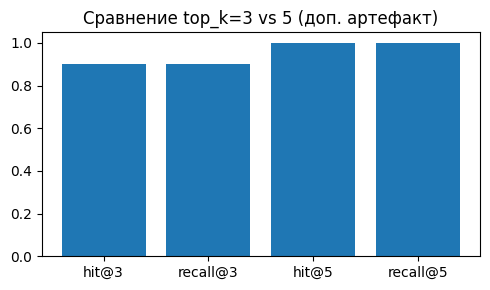

In [9]:
retrieval_eval_df.to_csv(ARTIFACT_DIR / "retrieval_eval.csv", index=False)
rag_df.to_csv(ARTIFACT_DIR / "rag_examples.csv", index=False)
before_after_df.to_csv(ARTIFACT_DIR / "retrieval_before_after_update.csv", index=False)
print("Сохранено:", list(ARTIFACT_DIR.glob("*.csv")))

summary = {
    "vectorization": VECTORIZER_KIND,
    "chunk_size": CHUNK_SIZE,
    "overlap": OVERLAP,
    "k_eval": K_EVAL,
    "metrics_initial": metrics_main,
    "experiment_topk": {"k3": m3, "k5": m5},
}
with open(ARTIFACT_DIR / "retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["hit@3", "recall@3", "hit@5", "recall@5"], [m3["hit@3"], m3["recall@3"], m5["hit@5"], m5["recall@5"]])
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение top_k=3 vs 5 (доп. артефакт)")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "retrieval_quality_plot.png", dpi=120)
plt.show()
